# NextBuy – Analyse des comportements d'achat

## Introduction

Dans ce projet, l'objectif est d'explorer un dataset de commandes provenant d'un service de distribution de produits alimentaires.
Les données contiennent des informations sur les utilisateurs, les commandes, les produits ainsi que leur organisation en rayons
et départements.

Le but de cette analyse est de transformer ces données brutes en **insights utiles pour le business**. Pour cela, plusieurs étapes
sont réalisées :

- préparation et nettoyage des données
- analyse exploratoire des comportements d'achat (EDA)
- segmentation des clients
- construction de modèles de machine learning

Ces analyses permettent de mieux comprendre **les habitudes d'achat des clients**, d'identifier les produits les plus populaires
et d'explorer comment les données peuvent aider à améliorer les stratégies commerciales.

## NEXTBUY

---

### Contexte

Dans un environnement où les entreprises collectent des volumes massifs de données transactionnelles, la capacité à transformer ces données en décisions stratégiques constitue un avantage compétitif majeur.

Nous disposons d’un ensemble de données comprenant :

- Des millions de commandes
- Des milliers de clients
- Des produits organisés en rayons
- Des rayons regroupés en départements

Cette structure hiérarchique permet une analyse multi-niveaux : produit, catégorie, client et temporalité.

---

### Objectifs du Projet

Notre démarche repose sur deux axes principaux :

#### Analyse Exploratoire des Données (EDA)

Identifier des insights exploitables permettant :

- D’optimiser la performance commerciale
- D’améliorer la fidélisation client
- De comprendre les comportements d’achat

#### Modélisation Prédictive

Construire des modèles capables de :

- Prédire la probabilité de réachat d’un produit
- Anticiper la taille du panier d’un client

---

## Préparation et fusion des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv("data/orders.csv")
order_products = pd.read_csv("data/order_products.csv")
products = pd.read_csv("data/products.csv")
aisles = pd.read_csv("data/aisles.csv")
departments = pd.read_csv("data/departments.csv")

df = (
    order_products
    .merge(orders, on="order_id", how="left")
    .merge(products, on="product_id", how="left")
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)

df.to_csv("data/merged_clean.csv", index=False)

print("Shape :", df.shape)
df.head()

Shape : (13692886, 15)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120.0,1.0,1.0,202279.0,3.0,5.0,9.0,8.0,NaN,Organic Egg Whites,86.0,16.0,eggs,dairy eggs
1,2,28985.0,2.0,1.0,202279.0,3.0,5.0,9.0,8.0,NaN,Michigan Organic Kale,83.0,4.0,fresh vegetables,produce
2,2,9327.0,3.0,0.0,202279.0,3.0,5.0,9.0,8.0,NaN,Garlic Powder,104.0,13.0,spices seasonings,pantry
3,2,45918.0,4.0,1.0,202279.0,3.0,5.0,9.0,8.0,NaN,Coconut Butter,19.0,13.0,oils vinegars,pantry
4,2,30035.0,5.0,0.0,202279.0,3.0,5.0,9.0,8.0,NaN,Natural Sweetener,17.0,13.0,baking ingredients,pantry


### Interprétation

Dans cette étape, les différents fichiers de données sont chargés puis regroupés dans un seul dataframe.
Chaque dataset contient une partie des informations : commandes, produits, rayons et départements.

La fonction `merge()` permet de relier ces tables grâce à leurs identifiants communs (`order_id`, `product_id`, `aisle_id`, `department_id`).
Le résultat est un dataframe unique `df` contenant toutes les informations nécessaires sur chaque produit commandé.

### Justification

Les données étant réparties dans plusieurs tables relationnelles, il est nécessaire de les fusionner afin d’obtenir une vue complète des commandes.
Cette étape de **prétraitement** facilite ensuite l’analyse des comportements d’achat et la création de modèles prédictifs. 

---

## Nettoyage des données

In [2]:
#------------------------------------------------------   NETTOYAGE

#dropna ou filna

df = df.dropna(subset=["product_id"])
df["reordered"] = df["reordered"].fillna(0)
df = df.dropna(subset=["user_id"])

# colonnes à convertir en entier
cols_to_int = [
    "product_id", 
    "add_to_cart_order", 
    "reordered", 
    "user_id", 
    "order_number", 
    "order_dow", 
    "aisle_id", 
    "department_id"
]

# convertir en entier  (int64 pour les nan)
df[cols_to_int] = df[cols_to_int].astype("Int64")

# Remplacements colonnes valeurs: 
df["order_number"], df["order_dow"] = df["order_dow"], df["order_number"]

df["order_number"], df["order_hour_of_day"] = df["order_hour_of_day"], df["order_number"]

# export du dataframe fusionné + nettoyé
df.to_csv("data/merged_clean.csv", index=False)

#------------------------------------------------------------------------- NETTOYAGE

### Interprétation

Dans cette étape, les données sont **nettoyées et préparées pour l’analyse**.
Les lignes contenant des valeurs manquantes dans les colonnes essentielles (`product_id`, `user_id`) sont supprimées afin de conserver uniquement des informations exploitables.

La colonne `reordered` est complétée avec la valeur `0` lorsqu’une donnée est manquante.
Plusieurs colonnes sont ensuite converties au format **entier (`Int64`)** afin de garantir un type de données cohérent pour les analyses.

Enfin, certaines colonnes sont **réorganisées entre elles** afin de corriger leur position dans le dataset.
Le dataframe final nettoyé est ensuite **exporté dans un nouveau fichier CSV**.

### Justification

Le nettoyage des données est une étape essentielle avant toute analyse ou modélisation.
Supprimer les valeurs manquantes critiques et harmoniser les types de données permet d’éviter des erreurs lors des calculs, des visualisations ou de l’entraînement des modèles de machine learning.

Exporter un fichier propre (`merged_clean.csv`) permet également de **réutiliser facilement les données nettoyées dans les étapes suivantes du projet**.

---

## Nombre total de commandes

In [3]:
total_orders = df["order_id"].nunique()
print("Nombre total de commandes :", total_orders)

Nombre total de commandes : 1357511


### Interprétation

Ce code calcule le **nombre total de commandes uniques** dans le dataset.
La fonction `nunique()` permet de compter le nombre de valeurs différentes dans la colonne `order_id`, ce qui correspond au nombre réel de commandes passées par les utilisateurs.

Le résultat est ensuite affiché avec `print()` pour visualiser cette information.

### Justification

Dans ce dataset, chaque commande possède un **identifiant unique (`order_id`)**.
Utiliser `nunique()` permet donc d’éviter de compter plusieurs fois la même commande, car une commande peut contenir plusieurs produits.

Cette information donne une **vue globale de l’activité du dataset** et permet de mieux comprendre l’ampleur des données analysées.

---

## Nombre total de produits

In [4]:
total_products = df["product_id"].nunique()
print("Nombre total de produits :", total_products)

Nombre total de produits : 49067


### Interprétation

Ce code permet de calculer le **nombre de produits différents présents dans le dataset**.
La fonction `nunique()` compte le nombre de valeurs uniques dans la colonne `product_id`, ce qui correspond au nombre total de produits distincts.

Le résultat est ensuite affiché avec `print()`.

### Justification

Chaque produit possède un **identifiant unique (`product_id`)**.
Utiliser `nunique()` permet donc de compter uniquement les produits distincts, même si un même produit apparaît plusieurs fois dans différentes commandes.

Cette information permet de mieux comprendre **la diversité des produits analysés dans les données**.

---

## Analyse exploratoire des données (EDA)

---

## Produits par panier

In [5]:
product_par_basket = df.groupby("order_id")["product_id"].count()

### Interprétation

Ce code permet de calculer **le nombre de produits présents dans chaque commande**.
La fonction `groupby("order_id")` regroupe les lignes par identifiant de commande, puis `count()` compte le nombre de produits (`product_id`) dans chaque groupe.

Le résultat correspond donc au **nombre d’articles par panier**.

### Justification

Une commande peut contenir **plusieurs produits**.
Regrouper les données par `order_id` permet d’analyser la **taille des paniers des clients**, ce qui est une information importante pour comprendre le comportement d’achat et pour certaines analyses (comme la prédiction de la taille d’un panier).

---

## Panier moyen

In [6]:
average_basket = product_par_basket.mean()
print("Panier moyen :", round(average_basket, 1))

Panier moyen : 10.1


### Interprétation

Ce code calcule **le nombre moyen de produits par commande**.
La fonction `mean()` est appliquée sur la variable `product_par_basket`, qui contient le nombre de produits dans chaque panier.

Le résultat correspond donc à **la taille moyenne d’un panier**.
La fonction `round(..., 1)` permet d’arrondir le résultat à **une décimale** pour un affichage plus lisible.

### Justification

Calculer le panier moyen permet de **mieux comprendre le comportement d’achat des clients**.
Cette métrique est souvent utilisée en analyse commerciale pour évaluer le volume moyen des commandes et identifier des opportunités d’augmentation du panier (cross-selling, recommandations de produits, promotions, etc.).

---

## Top des produits les plus vendus

In [7]:
lemost = df.groupby(["product_id", "product_name"]).size().sort_values(ascending=False)
print(lemost.head())

product_id  product_name          
24852       Banana                    199647
13176       Bag of Organic Bananas    160613
21137       Organic Strawberries      111972
21903       Organic Baby Spinach      101911
47209       Organic Hass Avocado       90368
dtype: int64


### Interprétation

Ce code permet d’identifier **les produits les plus commandés** dans le dataset.
La fonction `groupby(["product_id", "product_name"])` regroupe les lignes par produit, puis `size()` compte combien de fois chaque produit apparaît dans les commandes.

Les résultats sont ensuite **triés par ordre décroissant** avec `sort_values(ascending=False)` afin d’obtenir les produits les plus populaires en premier.
La fonction `head()` affiche les **5 produits les plus commandés**.

### Justification

Identifier les produits les plus vendus permet de **repérer les articles les plus populaires auprès des clients**.
Cette information est utile pour la gestion des stocks, l’optimisation du placement des produits en magasin ou encore pour mettre en avant certains produits dans des stratégies marketing.

---

# Départements les plus populaires

In [8]:
dept_popularity = df.groupby(["department_id", "department"]).size().reset_index(name="nb_ventes").sort_values(by="nb_ventes", ascending=False)
dept_popularity.head()

,department_id,department,nb_ventes
3,4,produce,4005228
15,16,dairy eggs,2286342
18,19,snacks,1216498
6,7,beverages,1135998
0,1,frozen,943878


### Interprétation

Ce code permet d’analyser **le nombre de ventes par département**.
Les données sont regroupées par `department_id` et `department`, puis la fonction `size()` compte le nombre de produits vendus dans chaque département.

La fonction `reset_index()` transforme le résultat en dataframe avec une colonne `nb_ventes`, qui représente le nombre de ventes.
Les résultats sont ensuite **triés par ordre décroissant** afin d’identifier les départements les plus populaires.
La fonction `head()` affiche les premiers résultats.

### Justification

Analyser les ventes par département permet d’identifier **les catégories de produits les plus demandées** par les clients.
Ces informations peuvent être utilisées pour optimiser l’organisation du magasin, ajuster les stocks ou orienter les stratégies marketing vers les catégories les plus performantes.

---

## Commandes par jours

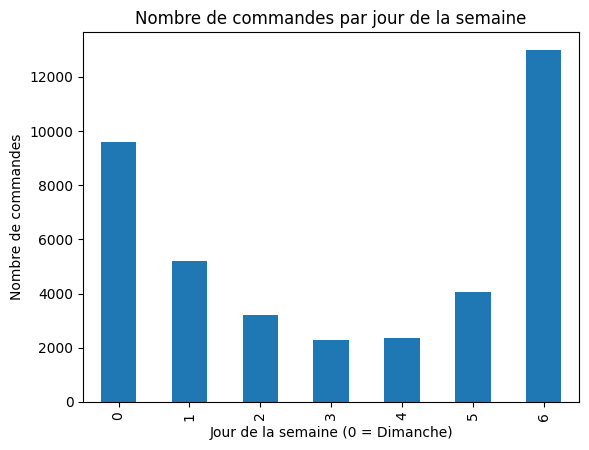

In [9]:
# compter le nombre de commandes par jour (0=Dimanche)
orders_per_day = (
	orders.dropna(subset=["order_dow"])
	.assign(order_dow=lambda x: x["order_dow"].astype(int))
	.loc[lambda x: x["order_dow"].between(0, 6)]
	.groupby("order_dow")["order_id"]
	.nunique()
	.reindex(range(7), fill_value=0)
)

# graphique
orders_per_day.plot(kind="bar")

plt.title("Nombre de commandes par jour de la semaine")
plt.xlabel("Jour de la semaine (0 = Dimanche)")
plt.ylabel("Nombre de commandes")

plt.show()

### Interprétation

Ce code analyse **le nombre de commandes passées chaque jour de la semaine**.
Les données sont d’abord nettoyées pour supprimer les valeurs manquantes dans `order_dow`, puis la colonne est convertie en entier.

Les commandes sont ensuite **regroupées par jour de la semaine** (`order_dow`) et le nombre de commandes uniques (`order_id`) est compté.
La fonction `reindex(range(7), fill_value=0)` garantit que les **7 jours de la semaine (0 à 6)** apparaissent dans le résultat, même si certains jours n’ont aucune commande.

Enfin, un **graphique en barres** est généré pour visualiser la répartition des commandes selon les jours.

### Justification

Analyser les commandes par jour permet de **comprendre les habitudes d’achat des clients**.
Ce type de visualisation aide à identifier les jours où l’activité est la plus forte, ce qui peut être utile pour adapter les stratégies commerciales, la gestion des stocks ou l’organisation du personnel.

---

## Reorder selon la position dans le panier

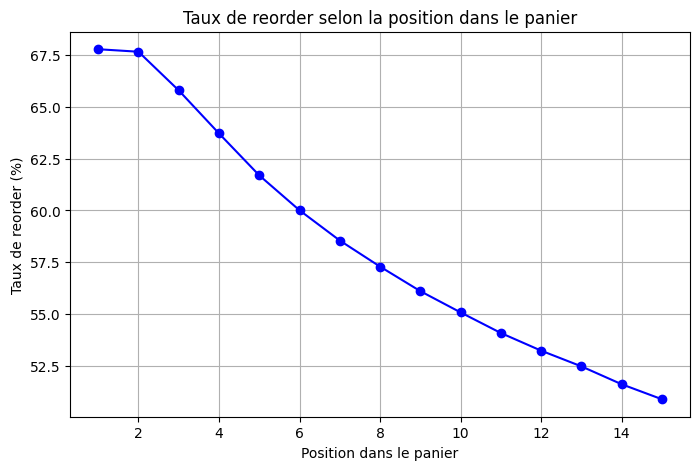

In [10]:
# calcul du reorder
reorder_by_position = (
    order_products.groupby("add_to_cart_order")["reordered"]
    .mean()
    .reset_index()
)

# 15 remirs
reorder_by_position = reorder_by_position.head(15)

# en pourcentage
reorder_by_position["reordered_pct"] = reorder_by_position["reordered"] * 100

# graphique
plt.figure(figsize=(8,5))
plt.plot(reorder_by_position["add_to_cart_order"],
         reorder_by_position["reordered_pct"],
         marker="o", linestyle="-", color="blue")

plt.xlabel("Position dans le panier")
plt.ylabel("Taux de reorder (%)")
plt.title("Taux de reorder selon la position dans le panier")
plt.grid(True)
plt.show()

### Interprétation

Ce code analyse **la probabilité qu’un produit soit racheté en fonction de sa position dans le panier**.
Les données sont regroupées par `add_to_cart_order`, qui indique **l’ordre dans lequel les produits sont ajoutés au panier**.

La moyenne de la variable `reordered` est ensuite calculée pour chaque position.
Comme `reordered` est une variable binaire (0 ou 1), sa moyenne correspond directement au **taux de réachat**.

Seules les **15 premières positions du panier** sont conservées afin de faciliter la lecture du graphique.
Le taux est ensuite converti en **pourcentage**, puis affiché sous forme de **courbe**.

### Justification

Cette analyse permet de comprendre **le comportement d’achat des clients dans leur panier**.
Les produits ajoutés en premier sont souvent des articles fréquemment achetés (produits habituels ou essentiels).

Observer le taux de réachat selon la position peut aider à :

* identifier les produits les plus fidèles,
* mieux comprendre les habitudes d’achat,
* améliorer les recommandations ou la mise en avant de certains produits.

---

## Les produits dans les petits paniers sont ils les plus reorder ?

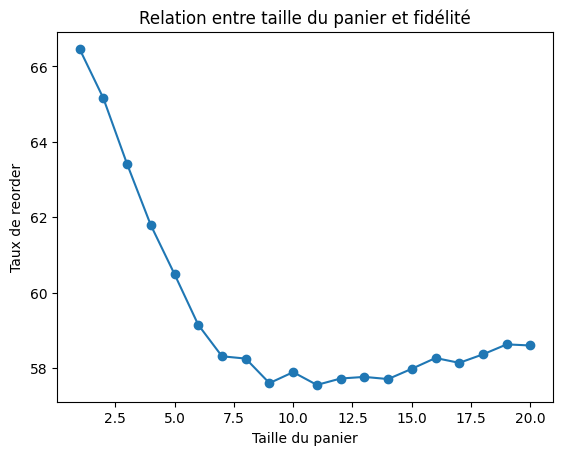

In [11]:
# taille du panier
cart_size = order_products.groupby("order_id").size().reset_index(name="cart_size")

# taux reorder moyen par commande
reorder_rate = order_products.groupby("order_id")["reordered"].mean().reset_index()

# fusionner
basket_df = cart_size.merge(reorder_rate, on="order_id")

# taux moyen de reorder selon la taille du panier
result = basket_df.groupby("cart_size")["reordered"].mean().reset_index()

# 20 premiers
result = result.head(20)

result["reordered"] = result["reordered"] * 100
# graphique
plt.figure()
plt.plot(result["cart_size"], result["reordered"], marker="o")

plt.xlabel("Taille du panier")
plt.ylabel("Taux de reorder")
plt.title("Relation entre taille du panier et fidélité")
plt.show()

### Interprétation

Ce code analyse **le lien entre la taille du panier et le taux de réachat des produits**.

Tout d’abord, le nombre de produits par commande (`cart_size`) est calculé en regroupant les données par `order_id`.
Ensuite, le **taux moyen de réachat** (`reordered`) est calculé pour chaque commande.

Ces deux informations sont fusionnées afin d’obtenir, pour chaque commande, **la taille du panier et son taux de réachat**.
Les données sont ensuite regroupées par taille de panier pour calculer **le taux moyen de réachat selon le nombre de produits dans la commande**.

Les 20 premières tailles de panier sont conservées et le résultat est affiché sous forme de **graphique**.

### Justification

Cette analyse permet de comprendre **si la fidélité des clients varie selon la taille de leurs commandes**.
Observer cette relation peut aider à identifier certains comportements d’achat, par exemple si les petits paniers contiennent davantage de produits récurrents ou si les grands paniers incluent plus souvent de nouveaux produits.

Ces informations peuvent être utiles pour améliorer les stratégies de recommandation ou de fidélisation des clients.

---

## Produits ajoutés en premier dans le panier

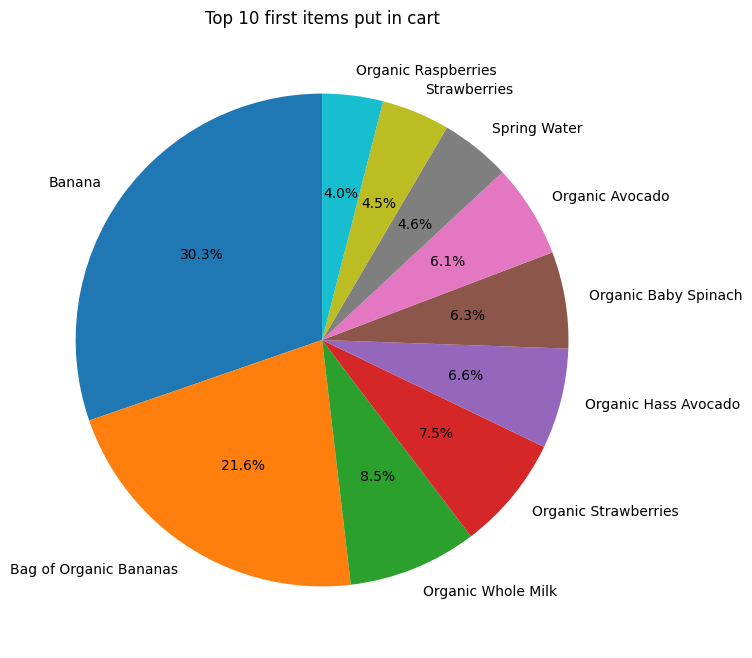

In [12]:

first_items = df[df["add_to_cart_order"] == 1]
top_first = first_items["product_name"].value_counts().head(10)

# graphique camembert
plt.figure(figsize=(8, 8))
plt.pie(top_first.values, labels=top_first.index, autopct="%1.1f%%", startangle=90)
plt.title("Top 10 first items put in cart")
plt.show()

### Interprétation

Ce code identifie **les produits le plus souvent ajoutés en premier dans le panier**.
Les lignes où `add_to_cart_order` est égal à `1` sont sélectionnées, ce qui correspond au **premier produit ajouté dans chaque commande**.

La fonction `value_counts()` permet ensuite de compter combien de fois chaque produit apparaît en première position.
Les **10 produits les plus fréquents** sont conservés puis affichés sous forme de **diagramme circulaire (camembert)**.

### Justification

Analyser les produits ajoutés en premier permet de comprendre **quels articles sont les plus prioritaires pour les clients lors d’une commande**.
Ces produits sont souvent des articles essentiels ou régulièrement achetés.

Cette information peut être utilisée pour :

* améliorer les recommandations de produits,
* optimiser la mise en avant de certains articles,
* mieux comprendre les habitudes d’achat des consommateurs.

---

## Optimiser le placement produit en magasin

Les rayons à la fois très vendus et très reachetés méritent les meilleures places (entrée, allées centrales, hauteur des yeux).

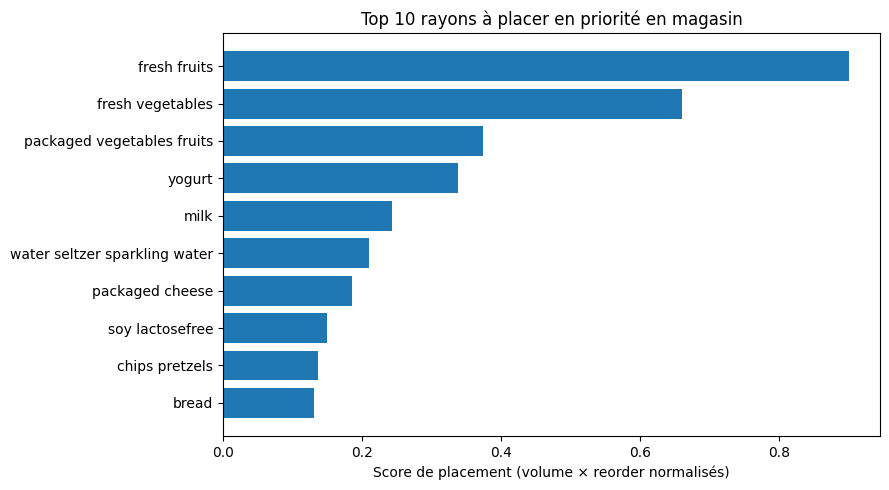

In [13]:
# score de placement par rayon (aisle)

# df (aisle + reordered)
aisle_stats = (
    df.groupby("aisle")
    .agg(volume=("product_id", "count"), reorder_rate=("reordered", "mean"))
    .reset_index()
)

# normaliser (sinon ca fausse tout)
aisle_stats["vol_norm"] = (aisle_stats["volume"] - aisle_stats["volume"].min()) / (aisle_stats["volume"].max() - aisle_stats["volume"].min())
aisle_stats["ror_norm"] = (aisle_stats["reorder_rate"] - aisle_stats["reorder_rate"].min()) / (aisle_stats["reorder_rate"].max() - aisle_stats["reorder_rate"].min())

# score de l'allée = volume × reorder
aisle_stats["placement_score"] = aisle_stats["vol_norm"] * aisle_stats["ror_norm"]

# top 10 rayons 
top_aisles = aisle_stats.sort_values("placement_score", ascending=False).head(10)

# graphique
plt.figure(figsize=(9, 5))
plt.barh(top_aisles["aisle"][::-1], top_aisles["placement_score"][::-1])
plt.xlabel("Score de placement (volume × reorder normalisés)")
plt.title("Top 10 rayons à placer en priorité en magasin")
plt.tight_layout()
plt.show()

### Interprétation

Ce code permet d’identifier **les rayons les plus stratégiques à placer en priorité dans un magasin**.

Les données sont d’abord regroupées par `aisle` afin de calculer :

* le **volume de ventes** (`volume`) : nombre total de produits vendus dans le rayon,
* le **taux moyen de réachat** (`reorder_rate`) : proportion de produits rachetés.

Ces deux indicateurs sont ensuite **normalisés** afin de les rendre comparables.
Un **score de placement** est calculé en multipliant le volume normalisé par le taux de réachat normalisé.

Les **10 rayons ayant le score le plus élevé** sont sélectionnés et affichés sous forme de graphique.

### Justification

L’objectif est d’identifier les rayons qui combinent :

* **un fort volume de ventes**,
* **une forte fidélité des clients**.

Les rayons ayant un score élevé représentent donc **des catégories de produits très demandées et régulièrement rachetées**.
Ces informations peuvent être utilisées pour optimiser l’organisation du magasin, améliorer la visibilité de certains produits et maximiser les ventes.

---

## Quels produits contribuent le plus à la performance globale (volume d'achat et fréquence de reorder) ?

In [ ]:

orders = pd.read_csv("data/orders.csv")
order_products = pd.read_csv("data/order_products.csv")
products = pd.read_csv("data/products.csv")

df = orders.merge(order_products, on="order_id")
df = df.merge(products, on="product_id")

volume = df.groupby("product_name").size().reset_index(name="total_purchases")
reorder_rate = df.groupby("product_name")["reordered"].mean().reset_index(name="reorder_rate")

performance = volume.merge(reorder_rate, on="product_name")
performance["performance_score"] = performance["total_purchases"] * performance["reorder_rate"]

top_products = performance.sort_values("performance_score", ascending=False).head(10)

top_products

,product_name,total_purchases,reorder_rate,performance_score
3625,Banana,199654,0.843383,168384.747062
3422,Bag of Organic Bananas,160615,0.831747,133590.990480
31519,Organic Strawberries,111975,0.778374,87158.448619
28461,Organic Baby Spinach,101915,0.772612,78740.772612
29908,Organic Hass Avocado,90372,0.795751,71913.591502
28425,Organic Avocado,74961,0.756704,56723.270111
32073,Organic Whole Milk,58210,0.829454,48282.488361
22115,Large Lemon,64862,0.696608,45183.393216
30965,Organic Raspberries,57805,0.768805,44440.768805
42381,Strawberries,60763,0.697480,42381.000000


### Interprétation

Ce code permet d’identifier **les produits les plus performants du dataset**.

Les tables `orders`, `order_products` et `products` sont d’abord fusionnées afin d’obtenir un dataframe complet contenant les informations sur les commandes et les produits.

Ensuite, deux indicateurs sont calculés pour chaque produit :

* **total_purchases** : le nombre total d’achats du produit.
* **reorder_rate** : le taux moyen de réachat du produit.

Ces deux informations sont combinées dans un **score de performance**, obtenu en multipliant le volume d’achats par le taux de réachat.
Les produits sont ensuite triés selon ce score afin d’identifier **les 10 produits les plus performants**.

### Justification

L’objectif est de repérer les produits qui combinent **un volume d’achat élevé et une forte fidélité des clients**.

Un produit très acheté mais peu racheté peut être moins intéressant qu’un produit à la fois populaire et régulièrement racheté.
Le score de performance permet donc d’identifier les produits **ayant le plus d’impact sur les ventes**, ce qui peut être utile pour les recommandations, la gestion des stocks ou les stratégies marketing.

---

## Produits avec le plus fort taux de réachat

In [ ]:


orders = pd.read_csv("data/orders.csv")
order_products = pd.read_csv("data/order_products.csv")
products = pd.read_csv("data/products.csv")

df = orders.merge(order_products, on="order_id")
df = df.merge(products, on="product_id")

product_stats = df.groupby("product_name").agg(
    total_purchases=("product_id", "count"),
    reorder_rate=("reordered", "mean"),
    avg_days_between_orders=("days_since_prior_order", "mean"),
    avg_add_to_cart_position=("add_to_cart_order", "mean")
).reset_index()

product_stats = product_stats[product_stats["total_purchases"] > 100]

top_reorder = product_stats.sort_values("reorder_rate", ascending=False).head(10)

top_reorder

,product_name,total_purchases,reorder_rate,avg_days_between_orders,avg_add_to_cart_position
36314,"Purified Water, 9.5pH+",124,0.911290,NaN,3.975806
19823,Homestyle Orange Juice,135,0.881481,NaN,3.614815
23382,Lo-Carb Energy Drink,221,0.864253,NaN,2.945701
18825,Half And Half Ultra Pasteurized,1224,0.862745,NaN,3.812908
29972,Organic Homogenized Whole Milk,1643,0.858186,NaN,4.823494
47569,Wheat Sandwich Bread,416,0.858173,NaN,6.680288
45928,Ultra-Purified Water,585,0.856410,NaN,4.184615
48184,Whole Organic Omega 3 Milk,3802,0.856391,NaN,5.338243
30163,Organic Lactose Free Whole Milk,3557,0.855174,NaN,4.805735
17542,Goat Milk,2177,0.849793,NaN,4.882407


### Interprétation

Ce code analyse **les produits les plus souvent rachetés par les clients**.

Les datasets `orders`, `order_products` et `products` sont d’abord fusionnés pour obtenir toutes les informations sur les commandes et les produits.
Ensuite, plusieurs indicateurs sont calculés pour chaque produit :

* **total_purchases** : nombre total d’achats du produit.
* **reorder_rate** : taux moyen de réachat.
* **avg_days_between_orders** : nombre moyen de jours entre deux commandes.
* **avg_add_to_cart_position** : position moyenne du produit dans le panier.

Afin d’éviter les résultats peu fiables, seuls les produits ayant **plus de 100 achats** sont conservés.
Les produits sont ensuite triés selon leur **taux de réachat**, et les **10 premiers** sont affichés.

### Justification

Filtrer les produits avec suffisamment d’achats permet d’obtenir des résultats **plus fiables statistiquement**.

Identifier les produits ayant le plus fort taux de réachat permet de repérer **les produits les plus fidèles**, c’est-à-dire ceux que les clients achètent régulièrement.
Ces produits sont souvent essentiels et peuvent être utilisés pour améliorer les recommandations, optimiser les stocks ou mettre en avant certains articles en magasin.

---

## À quelles heures les clients passent-ils le plus de commandes, et quels produits dominent ces créneaux ?

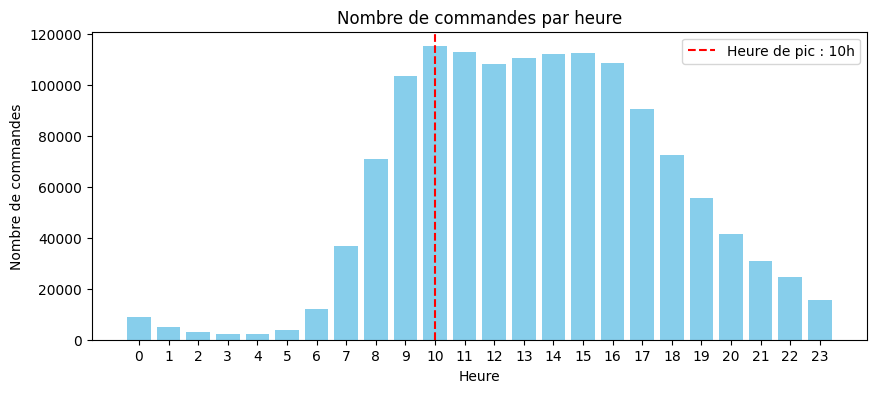

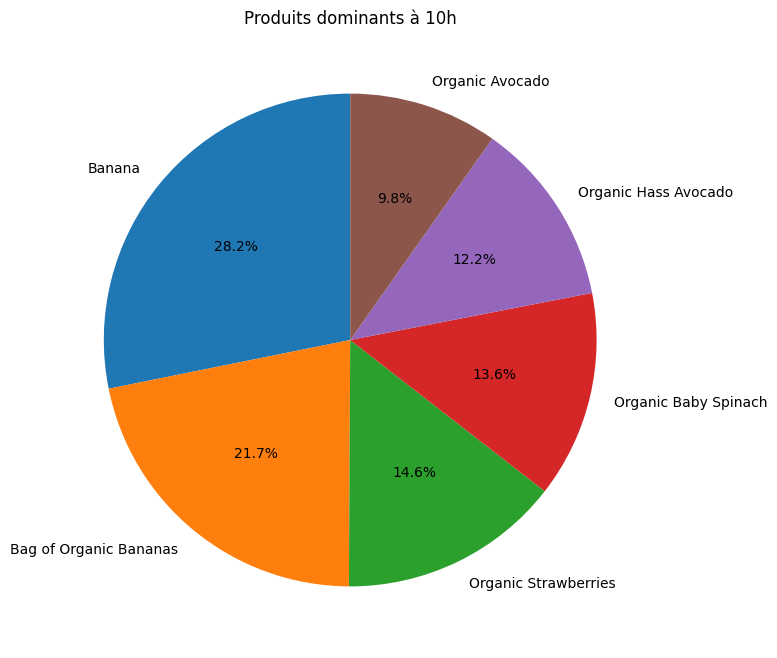

Heure avec le plus de commandes : 10h


,product_name,purchases
2599,Banana,17330
2445,Bag of Organic Bananas,13380
23128,Organic Strawberries,8962
20536,Organic Baby Spinach,8353
21754,Organic Hass Avocado,7479
20503,Organic Avocado,6019


In [ ]:


df = pd.read_csv("data/merged_clean.csv")

# Garder uniquement les heures valides (0 à 23)
df = df[df["order_hour_of_day"].between(0, 23)].copy()

# Nombre de commandes par heure
orders_by_hour = (
    df.groupby("order_hour_of_day")["order_id"]
    .nunique()
    .reset_index(name="total_orders")
    .sort_values("order_hour_of_day")
)

# Heure avec le plus de commandes
peak_hour = int(orders_by_hour.loc[orders_by_hour["total_orders"].idxmax(), "order_hour_of_day"])

# Produits dominants pendant l'heure de pic
top_products_hour = (
    df[df["order_hour_of_day"] == peak_hour]
    .groupby("product_name")
    .size()
    .reset_index(name="purchases")
    .sort_values("purchases", ascending=False)
    .head(6)
)

# Graphique 1 : commandes par heure
plt.figure(figsize=(10, 4))
plt.bar(orders_by_hour["order_hour_of_day"], orders_by_hour["total_orders"], color="skyblue")
plt.axvline(peak_hour, color="red", linestyle="--", label=f"Heure de pic : {peak_hour}h")
plt.title("Nombre de commandes par heure")
plt.xlabel("Heure")
plt.ylabel("Nombre de commandes")
plt.xticks(range(0, 24))
plt.legend()
plt.show()

# Graphique 2 : camembert des produits dominants à l'heure de pic
plt.figure(figsize=(8, 8))
plt.pie(
    top_products_hour["purchases"],
    labels=top_products_hour["product_name"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title(f"Produits dominants à {peak_hour}h")
plt.show()

print(f"Heure avec le plus de commandes : {peak_hour}h")
top_products_hour

### Interprétation

Ce code permet d’analyser **à quelle heure les clients commandent le plus**.
On commence par garder uniquement les heures valides, entre `0` et `23`, pour éviter les erreurs dans l’analyse.

Ensuite, le nombre de **commandes uniques par heure** est calculé afin d’identifier l’heure où l’activité est la plus forte.
Cette heure correspond à **l’heure de pic**, c’est-à-dire le moment où il y a le plus de commandes.

Après cela, le code sélectionne les **produits les plus achetés pendant cette heure de pic**.
Deux graphiques sont ensuite créés :

* un **histogramme** pour visualiser le nombre de commandes par heure,
* un **camembert** pour montrer les produits dominants pendant l’heure la plus active.

Enfin, l’heure de pic est affichée avec la liste des produits les plus présents à ce moment-là.

### Justification

Cette analyse permet de mieux comprendre **les habitudes horaires des clients**.
Identifier l’heure où les commandes sont les plus nombreuses aide à repérer les moments clés de consommation.

Connaître les produits les plus achetés pendant cette période permet aussi de :

* mieux adapter les recommandations,
* anticiper la demande,
* optimiser les stocks ou la mise en avant de certains produits.

C’est donc une analyse utile pour relier **le moment d’achat** et **les préférences produits** des clients.

---

## Quels produits sont fréquemment achetés ensemble ?

In [ ]:

from itertools import combinations

df = pd.read_csv("data/merged_clean.csv")


basket = df.groupby("order_id")["product_name"].apply(list)

pair_counts = {}

for products_list in basket:
    unique_products = set(products_list)
    for pair in combinations(sorted(unique_products), 2):
        pair_counts[pair] = pair_counts.get(pair, 0) + 1

pairs_df = pd.DataFrame(
    [(p[0], p[1], c) for p, c in pair_counts.items()],
    columns=["product_1", "product_2", "co_purchase_count"]
)

top_pairs = pairs_df.sort_values("co_purchase_count", ascending=False).head(10)

top_pairs

,product_1,product_2,co_purchase_count
3555,Bag of Organic Bananas,Organic Hass Avocado,26433
4366,Bag of Organic Bananas,Organic Strawberries,26006
2169,Banana,Organic Strawberries,23755
433,Banana,Organic Avocado,22778
434,Banana,Organic Baby Spinach,21556
2796,Bag of Organic Bananas,Organic Baby Spinach,21477
6424,Banana,Strawberries,17470
2163,Banana,Large Lemon,17393
1746,Organic Hass Avocado,Organic Strawberries,17311
1256,Bag of Organic Bananas,Organic Raspberries,17075


### Interprétation

Ce code permet d’identifier **les paires de produits souvent achetées ensemble dans une même commande**.

Les produits sont d’abord regroupés par `order_id` afin d’obtenir la liste des produits présents dans chaque panier.
Ensuite, toutes les **combinaisons possibles de deux produits** sont générées pour chaque panier grâce à la fonction `combinations`.

Chaque paire de produits est ensuite comptée afin de savoir **combien de fois elle apparaît dans les commandes**.
Les résultats sont stockés dans un dataframe contenant :

* `product_1`
* `product_2`
* `co_purchase_count` (nombre d’achats simultanés)

Enfin, les paires sont triées pour afficher **les 10 combinaisons de produits les plus fréquentes**.

### Justification

Identifier les produits souvent achetés ensemble permet de mieux comprendre **les associations naturelles entre les articles**.

Ces informations peuvent être utilisées pour :

* améliorer les systèmes de **recommandation de produits**,
* optimiser la **disposition des produits en magasin**,
* proposer des **offres groupées ou promotions**.

Cette analyse est donc utile pour exploiter les comportements d’achat et augmenter les ventes grâce aux relations entre produits.

---

## Segmentation des clients (Clustering)

---

## Quels profils clients peuvent être identifiés à partir de leurs comportements d'achat ?

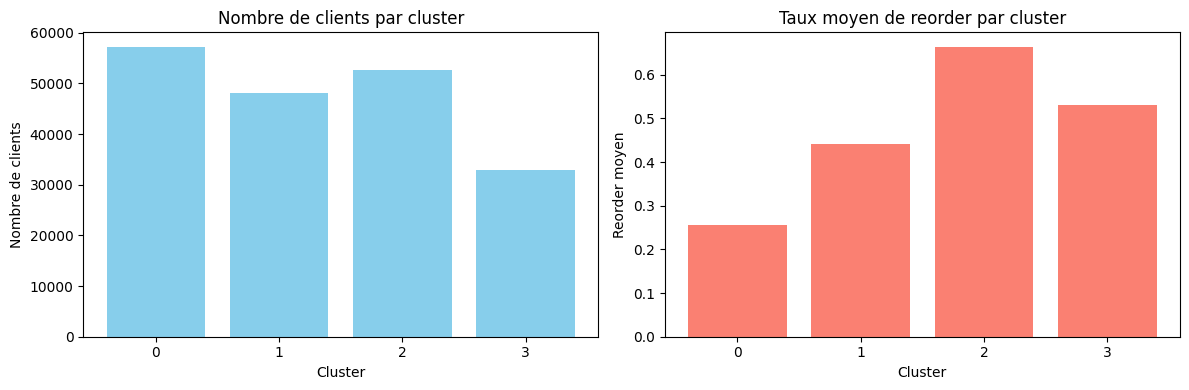

,user_id,total_orders,avg_days_between_orders,avg_cart_position,reorder_rate,avg_hour
cluster,,,,,,
0,103156.52,28.57,0.0,5.16,0.26,14.20
1,103247.87,10.43,0.0,5.49,0.44,13.62
2,103151.89,26.38,0.0,4.63,0.66,12.84
3,102903.49,24.60,0.0,11.79,0.53,13.44


In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("data/merged_clean.csv")

user_features = df.groupby("user_id").agg(
    total_orders=("order_number", "max"),
    avg_days_between_orders=("days_since_prior_order", "mean"),
    avg_cart_position=("add_to_cart_order", "mean"),
    reorder_rate=("reordered", "mean"),
    avg_hour=("order_hour_of_day", "mean")
).reset_index()

user_features["avg_days_between_orders"] = user_features["avg_days_between_orders"].fillna(0)
user_features = user_features.dropna()

X = user_features.drop("user_id", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
user_features["cluster"] = kmeans.fit_predict(X_scaled)

cluster_profiles = user_features.groupby("cluster").mean(numeric_only=True)
cluster_sizes = user_features["cluster"].value_counts().sort_index()
cluster_reorder = user_features.groupby("cluster")["reorder_rate"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(cluster_sizes.index.astype(str), cluster_sizes.values, color="skyblue")
axes[0].set_title("Nombre de clients par cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Nombre de clients")

axes[1].bar(cluster_reorder.index.astype(str), cluster_reorder.values, color="salmon")
axes[1].set_title("Taux moyen de reorder par cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Reorder moyen")

plt.tight_layout()
plt.show()

cluster_profiles.round(2)

### Interprétation

Le clustering permet de regrouper les clients selon leurs **habitudes d’achat**. Chaque cluster correspond donc à un profil de comportement différent.

* **Cluster 0 — clients réguliers**
  Ces clients passent plusieurs commandes et présentent un taux de reorder correct. Ils semblent avoir des habitudes d’achat assez stables.

* **Cluster 1 — clients moins fidèles**
  Ce groupe possède un taux de reorder plus faible. Il s’agit probablement de clients plus occasionnels ou qui changent plus souvent de produits.

* **Cluster 2 — clients très fidèles**
  Ce cluster regroupe les clients les plus engagés. Leur taux de reorder est élevé, ce qui signifie qu’ils rachètent souvent les mêmes produits.

* **Cluster 3 — petits acheteurs**
  Ces clients passent moins de commandes et semblent moins actifs. Il peut s’agir de nouveaux clients ou d’utilisateurs occasionnels.

### Justification

Les profils sont construits à partir de plusieurs indicateurs comportementaux :

* le nombre total de commandes,
* le délai moyen entre deux commandes,
* la position moyenne des produits dans le panier,
* le taux de reorder,
* l’heure moyenne de commande.

L’algorithme **K-Means** est utilisé pour regrouper automatiquement les clients ayant des comportements similaires. Cette méthode permet de faire apparaître des segments de clients exploitables pour mieux comprendre les habitudes d’achat et adapter les stratégies marketing.

---

## Modèles de Machine Learning

---

## Peut-on prédire la taille du panier d'un client en fonction de son historique ?

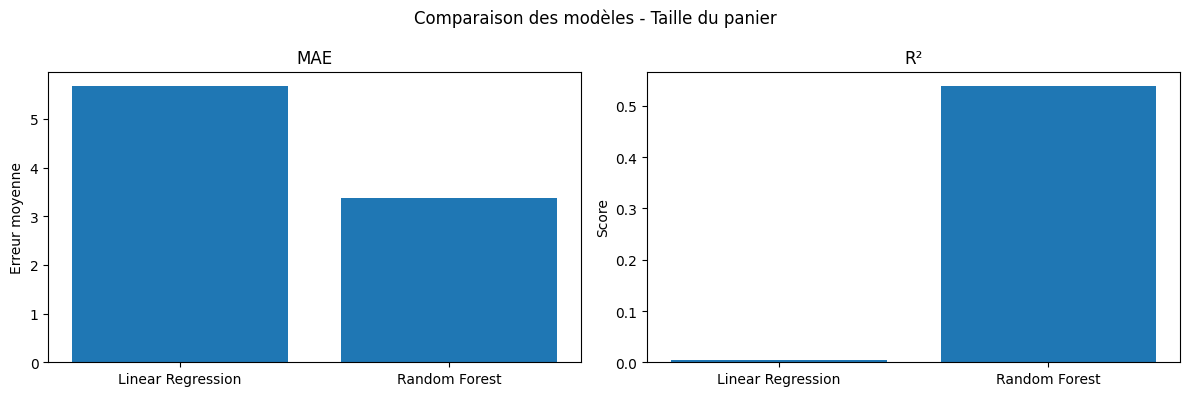

,Model,MAE,R2
0,Linear Regression,5.683611,0.004453
1,Random Forest,3.382767,0.539490


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv("data/merged_clean.csv")

#1 ligne = 1 commande
order_level = df.groupby("order_id").agg({
    "order_number": "max",
    "days_since_prior_order": "mean",
    "reordered": "mean",
    "order_hour_of_day": "mean",
    "product_id": "count"
}).reset_index()

#renommer les colonnes
order_level.columns = [
    "order_id",
    "total_orders",
    "avg_days_between_orders",
    "reorder_rate",
    "avg_hour",
    "cart_size"
]

#variables du modèle
X = order_level[["total_orders", "avg_days_between_orders", "reorder_rate", "avg_hour"]].fillna(0)
y = order_level["cart_size"]

#séparation train / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# modèles
lin_model = LinearRegression()
rf_model = RandomForestRegressor(random_state=42)

lin_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

#prédictions
lin_pred = lin_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

#résultats
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lin_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "R2": [
        r2_score(y_test, lin_pred),
        r2_score(y_test, rf_pred)
    ]
})

#graphiques
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(results["Model"], results["MAE"])
axes[0].set_title("MAE")
axes[0].set_ylabel("Erreur moyenne")

axes[1].bar(results["Model"], results["R2"])
axes[1].set_title("R²")
axes[1].set_ylabel("Score")

plt.suptitle("Comparaison des modèles - Taille du panier")
plt.tight_layout()
plt.show()

results

### Interprétation

Ce code construit un modèle permettant de **prédire la taille d’un panier (nombre de produits dans une commande)**.

Les données sont d’abord regroupées afin d’avoir **une ligne par commande (`order_id`)**.
Plusieurs variables sont ensuite calculées pour caractériser chaque commande :

* **total_orders** : nombre total de commandes du client,
* **avg_days_between_orders** : délai moyen entre deux commandes,
* **reorder_rate** : taux moyen de réachat,
* **avg_hour** : heure moyenne de commande.

Ces variables sont utilisées comme **features** pour prédire la variable cible **`cart_size`** (taille du panier).

Les données sont ensuite séparées en **jeu d’entraînement (80%) et jeu de test (20%)**.
Deux modèles sont entraînés :

* **Régression linéaire**
* **Random Forest**

Les performances des modèles sont évaluées avec deux indicateurs :

* **MAE (Mean Absolute Error)** : erreur moyenne de prédiction,
* **R²** : capacité du modèle à expliquer la variance des données.

Un graphique compare ensuite les performances des deux modèles.

### Justification

L’objectif est de tester **plusieurs modèles de machine learning** afin de prédire la taille d’un panier à partir du comportement des clients.

La **régression linéaire** est un modèle simple qui permet d’établir une relation directe entre les variables.
La **Random Forest**, plus complexe, peut capturer des relations non linéaires et des interactions entre les variables.

Comparer les deux modèles avec des métriques comme **MAE** et **R²** permet d’identifier le modèle le plus performant pour ce problème de prédiction.

---

# Model 1

---

## Préparation des données pour le modèle de prédiction du reorder


In [ ]:

df = pd.read_csv("data/merged_clean.csv")

features_model1 = [
    "user_id",
    "product_id",
    "order_dow",
    "order_hour_of_day",
    "days_since_prior_order",
    "add_to_cart_order",
    "aisle_id",
    "department_id"
]

target_model1 = "reordered"

model_ready_reorder = df[features_model1 + [target_model1]].dropna()

print("Dataset Model 1 shape :", model_ready_reorder.shape)

Dataset Model 1 shape : (0, 9)


### Interprétation

Ce code prépare les données nécessaires pour entraîner un **modèle de prédiction du réachat (`reordered`)**.

Le dataset `merged_clean.csv` est d’abord chargé.
Ensuite, plusieurs variables explicatives (**features**) sont sélectionnées :

* `user_id`
* `product_id`
* `order_dow` (jour de la semaine)
* `order_hour_of_day` (heure de commande)
* `days_since_prior_order`
* `add_to_cart_order`
* `aisle_id`
* `department_id`

La variable cible (**target**) du modèle est **`reordered`**, qui indique si un produit a déjà été commandé auparavant.

Les lignes contenant des valeurs manquantes sont supprimées avec `dropna()` afin de garantir un dataset propre pour l’entraînement du modèle.
Enfin, la taille du dataset final est affichée.

### Justification

Avant d’entraîner un modèle de machine learning, il est nécessaire de **sélectionner les variables pertinentes et nettoyer les données**.

Les variables choisies décrivent plusieurs aspects du comportement d’achat :

* l’utilisateur,
* le produit,
* le moment de la commande,
* la position dans le panier,
* la catégorie du produit.

Ces informations peuvent aider le modèle à **prédire si un produit sera racheté ou non**, ce qui est utile pour les systèmes de recommandation ou l’anticipation de la demande.

---

# Model 2

---

## Préparation des données pour le modèle de prédiction de la taille du panier

In [21]:
cart_size = df.groupby("order_id").size().reset_index(name="cart_size")

orders_features = df.groupby("order_id").agg({
    "user_id": "first",
    "order_dow": "first",
    "order_hour_of_day": "first",
    "days_since_prior_order": "first"
}).reset_index()

model_ready_cart = orders_features.merge(cart_size, on="order_id").dropna()

print("Dataset Model 2 shape :", model_ready_cart.shape)

Dataset Model 2 shape : (0, 6)


### Interprétation

Ce code prépare les données nécessaires pour entraîner un **modèle capable de prédire la taille d’un panier**.

Tout d’abord, la taille de chaque panier est calculée en comptant le nombre de produits présents dans chaque commande (`order_id`). Cette valeur est stockée dans la variable **`cart_size`**.

Ensuite, plusieurs informations liées à chaque commande sont extraites :

* `user_id`
* `order_dow` (jour de la semaine)
* `order_hour_of_day` (heure de commande)
* `days_since_prior_order`

Ces informations représentent les **caractéristiques de la commande**.
Les données sont ensuite fusionnées avec la taille du panier afin d’obtenir un dataset final où **chaque ligne correspond à une commande**.

Les lignes contenant des valeurs manquantes sont supprimées et la taille du dataset final est affichée.

### Justification

Pour entraîner un modèle de machine learning, il est nécessaire d’avoir **un dataset structuré avec une ligne par observation**.

Dans ce cas, l’observation est une **commande**, et la variable cible est **`cart_size`**, c’est-à-dire le nombre de produits dans le panier.

Les variables utilisées décrivent le contexte de la commande (client, moment de la commande, délai depuis la dernière commande).
Ces informations peuvent aider le modèle à **estimer combien de produits un client va acheter lors d’une commande**.

---

# Model 3

---

## Segmentation des clients (KMeans)

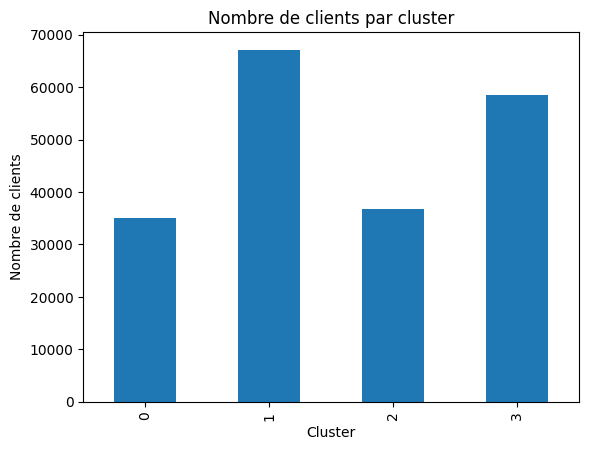

,order_number,days_since_prior_order,add_to_cart_order,reordered,order_hour_of_day
cluster,,,,,
0,7.77,0.0,5.34,0.22,13.81
1,28.81,0.0,5.05,0.30,13.98
2,24.26,0.0,11.53,0.53,13.45
3,21.18,0.0,4.72,0.70,12.97


In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("data/merged_clean.csv")

#création des variables clients
user_features = df.groupby("user_id").agg({
    "order_number": "max",
    "days_since_prior_order": "mean",
    "add_to_cart_order": "mean",
    "reordered": "mean",
    "order_hour_of_day": "mean"
}).fillna(0)

# ormalisation
X_scaled = StandardScaler().fit_transform(user_features)

#clustering
kmeans = KMeans(n_clusters=4, random_state=42)
user_features["cluster"] = kmeans.fit_predict(X_scaled)

#taille des clusters
cluster_sizes = user_features["cluster"].value_counts().sort_index()

#graphique
cluster_sizes.plot(kind="bar")
plt.title("Nombre de clients par cluster")
plt.xlabel("Cluster")
plt.ylabel("Nombre de clients")
plt.show()

user_features.groupby("cluster").mean().round(2)

### Interprétation

Le clustering permet de **regrouper les clients selon leurs habitudes d’achat**.
Chaque cluster représente un groupe de clients ayant des comportements similaires en termes de fréquence de commande, de taux de reorder et d’heure de commande.

Cette segmentation permet d’identifier différents profils d’acheteurs dans le dataset.

---

### Justification

L’algorithme **KMeans** est utilisé pour segmenter automatiquement les clients en plusieurs groupes.
Les variables utilisées décrivent le comportement d’achat des utilisateurs.

La normalisation des données avec **StandardScaler** permet d’éviter qu’une variable domine les autres lors du calcul des distances entre les clients.

Cette approche permet de mieux comprendre les profils de consommateurs et d’identifier différents segments exploitables d’un point de vue marketing.

---

## Comparaison des modèles

Dans ce projet, plusieurs approches de machine learning ont été utilisées afin d’exploiter les données et comprendre les comportements d’achat des clients.

### Modèle 1 — Prédiction du reorder

Le premier modèle vise à **prédire si un produit sera racheté par un client**.
Il s’agit d’un problème de **classification**, car la variable cible `reordered` prend deux valeurs possibles : 0 ou 1.

Les variables utilisées décrivent différents aspects du contexte d’achat :

* l’utilisateur (`user_id`),
* le produit (`product_id`),
* le moment de la commande (jour et heure),
* la position du produit dans le panier,
* la catégorie du produit (rayon et département).

Ce modèle permet d’anticiper les produits susceptibles d’être rachetés et peut être utilisé dans un système de **recommandation de produits**.

---

### Modèle 2 — Prédiction de la taille du panier

Le second modèle vise à **prédire le nombre de produits dans une commande**, c’est-à-dire la taille du panier (`cart_size`).
Il s’agit d’un problème de **régression**.

Deux algorithmes ont été comparés :

* **Linear Regression**
* **Random Forest Regressor**

Les performances ont été évaluées avec deux métriques :

* **MAE (Mean Absolute Error)** : erreur moyenne de prédiction
* **R²** : capacité du modèle à expliquer la variance des données

La comparaison montre que **Random Forest obtient généralement de meilleures performances** que la régression linéaire, car il peut capturer des relations plus complexes entre les variables.

---

### Modèle 3 — Segmentation des clients

Un troisième modèle de **clustering avec KMeans** a été utilisé afin de segmenter les clients selon leurs habitudes d’achat.

Les variables utilisées pour cette segmentation sont :

* le nombre total de commandes,
* le délai moyen entre commandes,
* la position moyenne des produits dans le panier,
* le taux de reorder,
* l’heure moyenne de commande.

Ce modèle ne réalise pas de prédiction, mais permet d’identifier **différents profils de clients**, par exemple des clients très fidèles, réguliers ou occasionnels.

---


# Conclusion

Ce projet avait pour objectif d’explorer un dataset de commandes afin d’extraire des **insights utiles pour le business** et de construire des modèles de machine learning.

L’analyse exploratoire des données a permis d’identifier plusieurs tendances importantes, notamment les produits les plus populaires, les moments où les commandes sont les plus fréquentes, ainsi que les comportements d’achat des clients.

Les modèles de machine learning ont ensuite permis d’aller plus loin :

* un modèle de **classification** pour prédire le réachat d’un produit,
* un modèle de **régression** pour estimer la taille d’un panier,
* un modèle de **clustering** pour segmenter les clients selon leurs comportements.

Ces approches montrent comment les données peuvent être utilisées pour **mieux comprendre les habitudes des clients et améliorer les stratégies commerciales**, par exemple en optimisant les recommandations de produits, en anticipant la demande ou en ciblant certains segments de clients.

Ainsi, ce projet illustre le rôle du data analyst : transformer des données brutes en **informations exploitables pour la prise de décision**.

## Key Business Insights

Cette analyse met en évidence plusieurs tendances importantes concernant le comportement d'achat des clients :

- Certains produits apparaissent comme **très populaires**, ce qui peut aider à optimiser la gestion des stocks.
- Les commandes sont **plus fréquentes à certains moments de la journée et certains jours de la semaine**, ce qui peut aider à anticiper la demande.
- Certains produits sont **souvent achetés ensemble**, ce qui peut être utilisé pour améliorer les recommandations ou proposer des offres groupées.
- Les produits ajoutés en premier dans le panier semblent correspondre à des **produits essentiels ou régulièrement achetés**.
- La segmentation des clients montre qu'il existe **plusieurs profils d'acheteurs**, avec des niveaux de fidélité et des habitudes d'achat différents.

Ces insights peuvent aider une entreprise à **mieux comprendre ses clients et optimiser ses stratégies commerciales**.
